In [ ]:
"""Code for testing and creating Poincare maps from the numerical 
solutions of the Lorenz system."""

In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pynamicalsys import ContinuousDynamicalSystem as cds, PlotStyler

In [2]:
cds.available_models()

['lorenz system',
 'henon heiles',
 'rossler system',
 '4d rossler system',
 'duffing']

In [3]:
cds.available_integrators()

['rk4', 'rk45']

In [4]:
ds = cds(model="lorenz system")

In [5]:
ds.info

{'description': '3D Lorenz system',
 'equation': <IPython.core.display.Math object>,
 'equation_readable': "x' = σ(y − x), y' = x(ρ − z) − y, z' = xy − βz",
 'notes': 'Classic Lorenz 1963 model of atmospheric convection. Exhibits chaotic dynamics for some parameter values.',
 'has_jacobian': True,
 'has_variational_equations': True,
 'equations_of_motion': CPUDispatcher(<function lorenz_system at 0x117160b80>),
 'jacobian': CPUDispatcher(<function lorenz_jacobian at 0x117160c20>),
 'dimension': 3,
 'number_of_parameters': 3,
 'parameters': ['sigma', 'rho', 'beta']}

In [6]:
total_time = 50
u = [1, 1, 1]
parameters = [10, 28, 8/3]
time_step = 1e-04

In [10]:
total_time = 50
u = [1, 1, 1] # initial condition remain fixed
parameters = [10, 28, 8/3] # A given parameter is alterred
time_step = 1e-04 # time step for numerical integration

In [7]:
ds.integrator("rk4", time_step=time_step)
trajectory = ds.trajectory(u, total_time, parameters=parameters)
trajectory.shape # time, x, y, z

(500000, 4)

In [8]:
print(trajectory)

[[ 1.00000000e-04  1.00000130e+00  1.00259988e+00  9.99833486e-01]
 [ 2.00000000e-04  1.00000520e+00  1.00519952e+00  9.99667276e-01]
 [ 3.00000000e-04  1.00001169e+00  1.00779894e+00  9.99501371e-01]
 ...
 [ 4.99998000e+01 -3.83218294e+00 -1.63003288e+00  2.53014238e+01]
 [ 4.99999000e+01 -3.82998232e+00 -1.63090486e+00  2.52953023e+01]
 [ 5.00000000e+01 -3.82778479e+00 -1.63177849e+00  2.52891823e+01]]


In [40]:
# To plot the Poincare map the trajecortories will need to be varied by a
# parameter or initial condition. When the solution crosses a given plane
# (e.g. z=25) the (x,y) coordinates will be recorded and plotted.

# Generting a varied set of parameters
varied_param = np.linspace(0, 35, 40)

total_time = 50
u = [1, 1, 1]
time_step = 1e-04

# Adding the varied parameters to the varied parameters
varied_parameters = np.column_stack((
    np.full_like(varied_param, 10, dtype=float),
    varied_param,
    np.full_like(varied_param, 8/3, dtype=float)
))
    
print(varied_parameters.shape)

# Setting the integrator with the chosen time step
ds = cds(model="lorenz system")
ds.integrator("rk4", time_step=time_step)

# Running the trajectories for each parameter set
trajectories = []
for params in varied_parameters:
    traj = ds.trajectory(u, total_time, parameters=params)
    trajectories.append(traj)

print(len(trajectories))

(40, 3)
40


<Figure size 640x480 with 0 Axes>

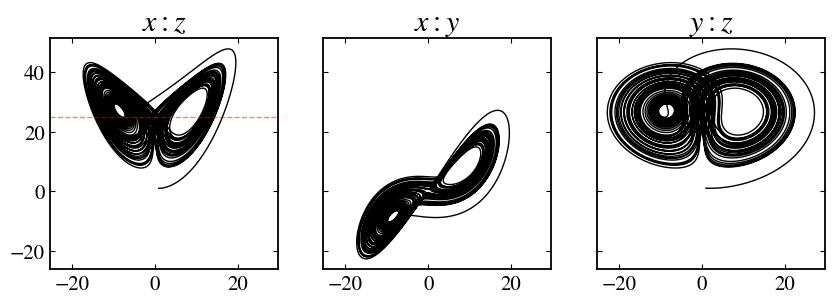

In [41]:
# Plotting one trajectory as the pairwise plots x:y, x:z, y:z  to get an idea of a suitable Poincare section
ps = PlotStyler(fontsize=18)
ps.apply_style()
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 3))
ax[0].plot(trajectory[:, 1], trajectory[:, 3], "k")
ax[0].set_title(f"$x:z$")

ax[1].plot(trajectory[:, 1], trajectory[:, 2], "k")
ax[1].set_title(f"$x:y$")

ax[2].plot(trajectory[:, 2], trajectory[:, 3], "k")
ax[2].set_title(f"$y:z$")

# Adding a horizontal line at z=25 and x > 0 to indicate a possible Poincare section in the first subplot
ax[0].axhline(25, color="red", linestyle="--", alpha=0.5)

[[-6.85204148 -7.1744897  24.26777567]
 [ 5.837878    6.21002991 22.92099374]]


<Figure size 640x480 with 0 Axes>

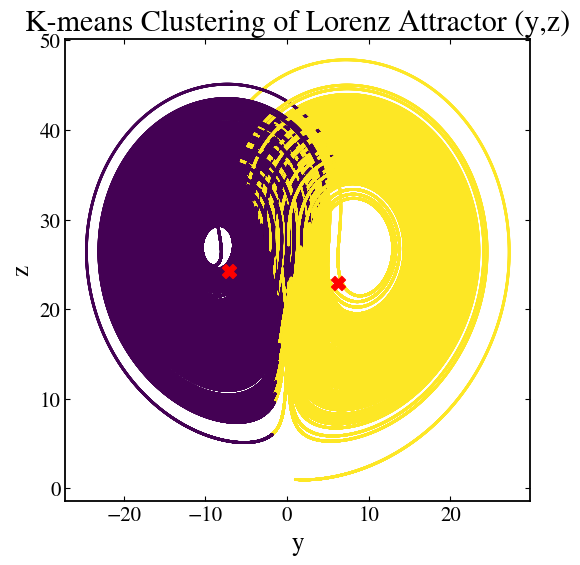

In [87]:
# Locating the hyperplane for a Poincare section for single attractor to generate a discrete map for the attractor.

total_time = 200
u = [1, 1, 1]
parameters = [10, 28, 8/3]
time_step = 1e-04

ds.integrator("rk4", time_step=time_step)
trajectory = ds.trajectory(u, total_time, parameters=parameters)
trajectory.shape 

traj = trajectory

# Identifying the separate components of the attractor using K means clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(traj[:, 1:4])
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print(centroids)
# Plotting the clusters to identify a suitable Poincare section
ps = PlotStyler(fontsize=18)
ps.apply_style()
plt.figure(figsize=(6, 6))
plt.scatter(traj[:, 2], traj[:, 3], c=labels, cmap='viridis', s=1)
plt.scatter(centroids[:, 1], centroids[:, 2], c='red', s=100, marker='X') # centroids
plt.xlabel('y')
plt.ylabel('z')
plt.title('K-means Clustering of Lorenz Attractor (y,z)')

# Having identified the centroids these are used to define a Poincare section
# A plane perpendicular to the line connecting the centroids to point on the outer edge of the attractor cluster
centroid1, centroid2 = centroids

Number of Poincare points: (116, 2)


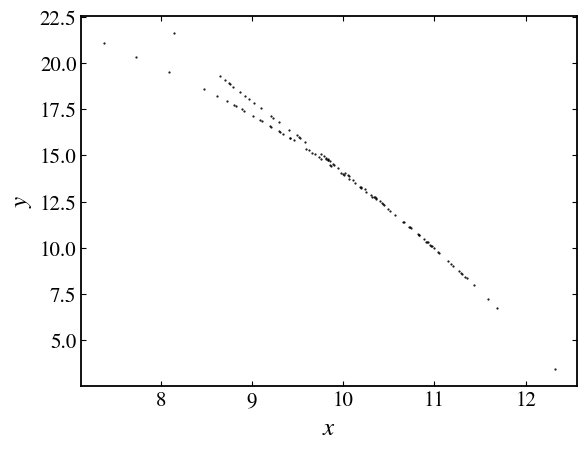

In [89]:
# Creating a hyperplane in one dimension lower than the system, is the size of the domain of the system
# For Poincare section 1 (plane perpendicular to line connecting centroids)
poincare_points = []
j = 0

x = traj[:, 1]
y = traj[:, 2]
z = traj[:, 3]
    
"""# Finding where the trajectory crosses the plane z=25 and x=0
for i in range(1, len(z)):
    if z[i-1] < centroid2[2] and z[i] > centroid2[2]:
        # Linear interpolation to find the exact crossing point
        x_cross = (x[i] + x[i-1])/2.0
        y_cross = (y[i] + y[i-1])/2.0
        poincare_points.append((x_cross,y_cross))
    """

# Finding where the trajectory crosses the plane z=25 and x=0
for i in range(1, len(z)):
    if x[i-1] < centroid2[0] and x[i] > centroid2[0]:
        # Linear interpolation to find the exact crossing point
        y_cross = (y[i] + y[i-1])/2.0
        z_cross = (z[i] + z[i-1])/2.0
        poincare_points.append((y_cross,z_cross))
    
poincare_points = np.array(poincare_points)

print(f"Number of Poincare points: {poincare_points.shape}")

plt.scatter(poincare_points[:,0],poincare_points[:,1],alpha=1,s=0.3,c='black')
#This section produces a 2-D plot of some of the products
#produced
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.show()

Number of Poincare points: (17, 2)


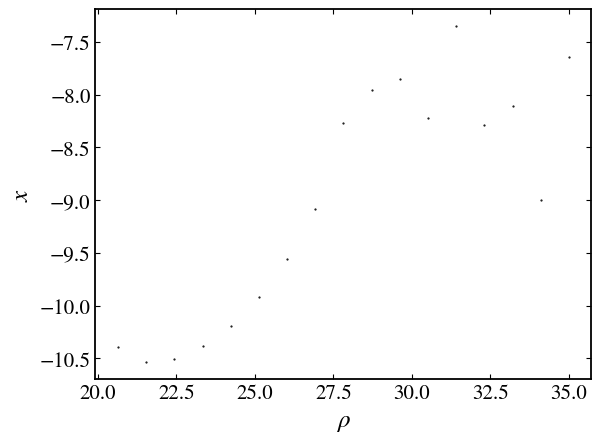

In [72]:
# For looping through the trajectories and extracting the Poincare points
poincare_points = []
j = 0

for traj in trajectories:
    # Extracting the x, y, z coordinates
    x = traj[:, 1]
    y = traj[:, 2]
    z = traj[:, 3]
    
    # Finding where the trajectory crosses the plane z=25 and x=0
    for i in range(1, len(z)):
        if z[i-1] < 25 and z[i] > 25 and x[i] < 0:
            # Linear interpolation to find the exact crossing point
            x_cross = (x[i] + x[i-1])/2.0
            poincare_points.append((varied_param[j],x_cross))
            break
    
    j += 1
    
poincare_points = np.array(poincare_points)

print(f"Number of Poincare points: {poincare_points.shape}")

plt.scatter(poincare_points[:,0],poincare_points[:,1],alpha=1,s=0.3,c='black')
#This section produces a 2-D plot of some of the products
#produced
plt.xlabel(r'$\rho$')
plt.ylabel(r'$x$')

plt.show()
            